# Numerische Ableitung

## Vertiefung

### Übersicht

1. Fehler: Abhängigkeit und Schätzung
2. Ableitung ausgehend von (ungleichmässig verteilten) Daten
3. Vergleich mit NumPy Gradient

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Fehler: Abhängigkeit und Schätzung

In der Einarbeitug haben wir gesehen, dass der Fehler der numerischen Ableitung von der Schrittweite $h$ abhängt. Wir untersuchen dies hier noch etwas genauer.

Dazu betrachten wir die Funktion

$$ f(x) = x^5 + 4 x^4 + x^3 - 10 x^2 - 4 x + 8 $$

deren Ableitung 

$$ f'(x) = 5 x^4 + 16 x^3 + 3 x^2 - 20 x - 4 $$

ist. Es sind beides Polynome, so dass wir sie mithilfe von [`np.polynomial.Polynomial`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.html#numpy.polynomial.polynomial.Polynomial) repräsentieren und berechnen können.

In [2]:
f = np.polynomial.Polynomial([8, -4, -10, 1, 4, 1])
f

Polynomial([  8.,  -4., -10.,   1.,   4.,   1.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

Solche NumPy Polynome können mit der Methode [`Polynomial.deriv()`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.deriv.html#numpy.polynomial.polynomial.Polynomial.deriv) analytisch abgeleitet werden

In [3]:
fprime = f.deriv()
fprime

Polynomial([ -4., -20.,   3.,  16.,   5.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

Wir schätzen die Ableitung einmal mit dem Vorwärtsdifferenzenquotienten und einmal mit dem zentralen Differenzenquotienten.

In [4]:
def deriv_forward(f, x, h):
    return (f(x + h) - f(x)) / h


def deriv_central(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

und vergleichen die Ergebnisse mit der analytischen Ableitung.

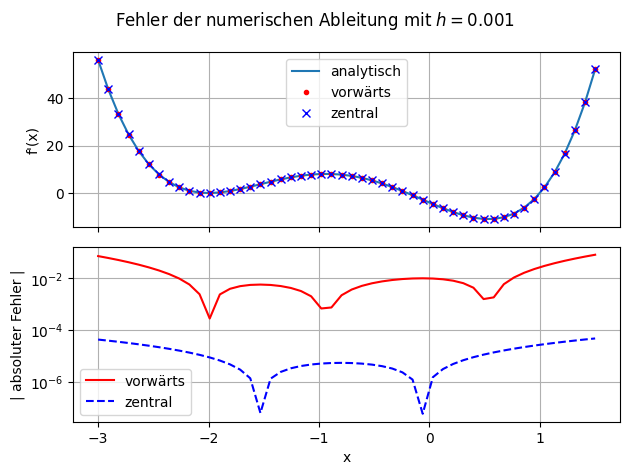

In [5]:
h = 1e-3

x = np.linspace(-3, 1.5)
yprime = fprime(x)
yprime_forward = deriv_forward(f, x, h)
yprime_central = deriv_central(f, x, h)

D_forward = yprime_forward - yprime
D_central = yprime_central - yprime

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(x, yprime, label="analytisch")
ax1.plot(x, yprime_forward, "r.", label="vorwärts")
ax1.plot(x, yprime_central, "bx", label="zentral")
ax1.set_ylabel("f'(x)")
ax1.legend()
ax1.grid()

ax2.plot(x, np.abs(D_forward), "r", label="vorwärts")
ax2.plot(x, np.abs(D_central), "b--", label="zentral")
ax2.set_xlabel("x")
ax2.set_ylabel("| absoluter Fehler |")
ax2.set_yscale("log")
ax2.grid()
plt.legend()

plt.suptitle(f"Fehler der numerischen Ableitung mit $h = {h}$")
plt.tight_layout()
plt.show()

Der zenrale Differenzenquotient schätzt die Ableitung also viel besser als der Vorwärtsdifferenzenquotient. Machen wir einen Vergleich an einer Stelle $x_0$ und variieren die Schrittweite $h$.

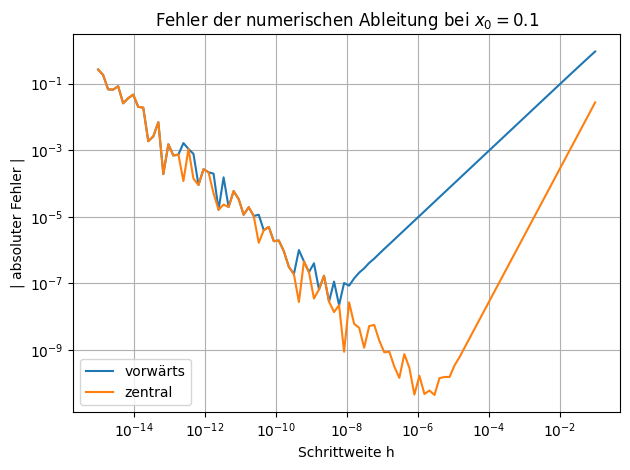

In [6]:
h = np.logspace(-15, -1, 100)
# h = np.linspace(1e-15, 0.1, 100)
x0 = 0.1

yprime = fprime(x0)
yprime_forward = deriv_forward(f, x0, h)
yprime_central = deriv_central(f, x0, h)

D_forward = yprime_forward - yprime
D_central = yprime_central - yprime

plt.plot(h, np.abs(D_forward), label="vorwärts")
plt.plot(h, np.abs(D_central), label="zentral")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Schrittweite h")
plt.ylabel("| absoluter Fehler |")
plt.grid()
plt.legend()
plt.title(f"Fehler der numerischen Ableitung bei $x_0={x0}$")
plt.tight_layout()
plt.show()

Beobachtungen:

- Der Fehler des Vorwärtsdifferenzenquotienten ist linear in $h$ (Gerade mit Steigung 1 im doppelt logarithmischen Diagram).
  $$ \dfrac{f(x_0+h) - f(x_0)}{h} - f'(x_0) = O(h) $$

- Der Fehler des zentralen Differenzenquotienten ist quadratisch in $h$ (Gerade mit Steigung 2 im doppelt logarithmischen Diagram) und ergibt eine wesentlich bessere Schätzung.
  $$ \dfrac{f(x_0+h) - f(x_0-h)}{2h} - f'(x_0) = O(h^2) $$

- Beide Differenzenquotienten stossen bei sehr kleinen $h$ an numerische Grenzen. Grund ist die Auslöschung bei der Subtraktion von fast gleich grossen Zahlen: $f(x-h)-f(x)$.

Wie $h$ idealerweise gewählt wird, hängt von der Form der Funktion ab. Für den zentralen Differenzenquozienten gibt es die Faustregel

$$ h \approx \sqrt[3]{\varepsilon} $$

wobei $\varepsilon$ die Maschinenpräzision ist. Für 64-bit Gleitkommazahlen ist ergibt dies $h \approx 5\times 10^{-6}$.

Bemerkung: Es gibt auch eine bessere Methode, die mithilfe der Taylorentwicklung der Funktion, deren Ableitung mit einem Fehler der Ordnung $O(h^4)$ schätzt, siehe [Numerische Differentiation - Wikipedia](https://de.wikipedia.org/wiki/Numerische_Differentiation).

### 2. Ableitung ausgehend von Daten

Wie gehen wir vor, wenn wir keine analytische Funktion gegeben haben, sondern nur Datenpunkte?

Gegeben sind also $n$ Datenpunkte $(x_i, y_i)$, $i = 0, 1, \ldots, n-1$.


#### a) Gleichmässig verteilte Punkte

Sind alle $x$-Werte gleich weit voneinander entfernt, $x_{i+1} = x_{i} + h$ (äquidistant), so können wir analog zur Methode für die Ableitung von Funktionen den *zentralen Differenzenquotienten* nehmen:

$$ y'_i = \frac{y_{i+1} - y_{i-1}}{2h}\,,\ i = 1, 2, \ldots, n-2 $$

Am Rand, also für $i=0$ und $i=n-1$ klappt dies nicht mehr und man beschränkt sich eben auf den vorwärts- bzw. rückwärtsgerichteten Differenzenquotienten:

$$ y'_0 = \frac{y_{1} - y_{0}}{h}\,,\quad y'_{n-1} = \frac{y_{n-1} - y_{n-2}}{h} $$


#### b) Ungleichmässig verteilte Punkte (allgemeiner Fall)

Sind die Punkte nicht gleichmässig verteilt, können wir trotzdem den Mittelwert des vorwärts- und rückwärtsgerichteten Differenzenquotienten nehmen. 

$$ y'_i = \frac{1}{2}\left( \frac{y_{i+1} - y_{i}}{x_{i+1} - x_{i}} + \frac{y_{i} - y_{i-1}}{x_{i} - x_{i-1}} \right)\,,\ i = 1, 2, \ldots, n-2 $$

und an den Rändern entsprechend

$$ y'_0 = \frac{y_{1} - y_{0}}{x_{1} - x_{0}}\,,\quad y'_{n-1} = \frac{y_{n-1} - y_{n-2}}{x_{n-1} - x_{n-2}} $$

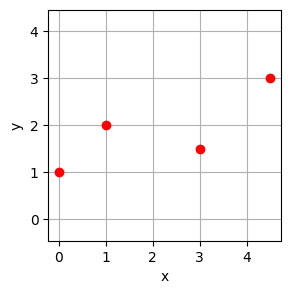

In [7]:
# Beispiel

x = np.array([0, 1, 3, 4.5])
y = np.array([1, 2, 1.5, 3])

plt.figure(figsize=(3, 3))
plt.plot(x, y, "ro")
plt.axis("equal")  # equal scaling in x and y
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

In [8]:
dx = np.diff(x)
dy = np.diff(y)
dydx = dy / dx
dydx

array([ 1.  , -0.25,  1.  ])

In [9]:
yprime = np.array(
    [
        dydx[0],
        (dydx[0] + dydx[1]) / 2,
        (dydx[1] + dydx[2]) / 2,
        dydx[-1],
    ]
)
yprime

array([1.   , 0.375, 0.375, 1.   ])

#### Implementation

- Wir berechnen die Differenzen benachbarter Punkte mit [`np.diff`](https://numpy.org/doc/stable/reference/generated/numpy.diff.html) und daraus die Differenzenquotienten.
- Dann verschieben wir diese gegenüber einander und addieren sie, um den zentralen Differenzenquotienten zu erhalten.

In [10]:
def deriv_data(x, y):
    dydx = np.diff(y) / np.diff(x)
    yprime = np.empty_like(y)
    yprime[0] = dydx[0]
    yprime[-1] = dydx[-1]
    yprime[1:-1] = (dydx[:-1] + dydx[1:]) / 2
    return yprime

Für einen Test samplen wir zufällige Punkte aus der Funktion $f(x)$ und schätzen die Ableitung.

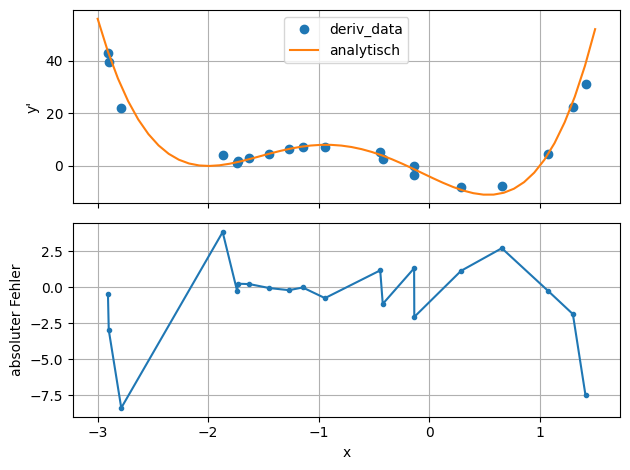

In [11]:
# Messdaten erzeugen
rng = np.random.default_rng(123456)
x_data = np.sort(rng.uniform(-3, 1.5, 20))
y_data = f(x_data)

# numerische Ableitung und ihren Fehler berechnen
yprime_data = deriv_data(x_data, y_data)
D_yprime = yprime_data - fprime(x_data)

# analytische Ableitung
x = np.linspace(-3, 1.5)
yprime = fprime(x)

# Darstellung
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# ... der Ableitungen
ax1.plot(x_data, yprime_data, "o", label="deriv_data")
ax1.plot(x, yprime, label="analytisch")
ax1.set_ylabel("y'")
ax1.legend()
ax1.grid()

# ... des Fehlers
ax2.plot(x_data, D_yprime, ".-")
ax2.set_xlabel("x")
ax2.set_ylabel("absoluter Fehler")
ax2.grid()

plt.tight_layout()
plt.show()

### 3. Vergleich mit NumPy Gradient

NumPy bietet die Funktion [`np.gradient`](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html) für die Berechnung von Ableitungen an.

Der Parameter `edge_order` bestimmt, wie die Ableitung an den Rändern berechnet wird. Mit `edge_order=1` wird einfach der vorwärts- bzw. rückwärtsgerichtete Differenzenquotient zum nächsten Punkt verwendet, mit `edge_order=2` wird auch noch der übernächste Punkt miteinbezogen. Ausprobieren!

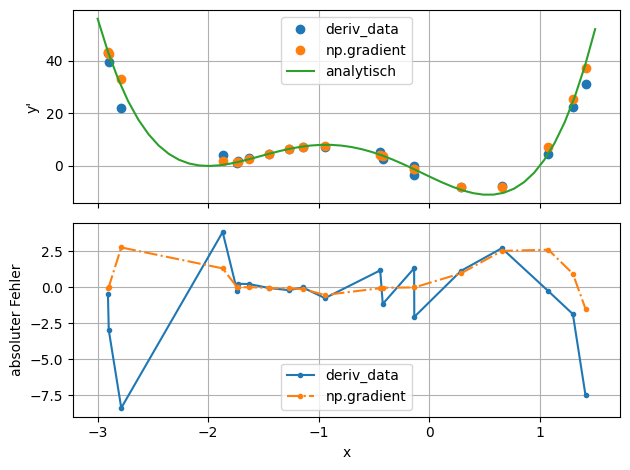

In [12]:
# Ableitung mit np.gradient und Fehler der Schätzung berechnen
grad = np.gradient(y_data, x_data, edge_order=2)
D_grad = grad - fprime(x_data)

# Darstellung
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# ... der Ableitungen
ax1.plot(x_data, yprime_data, "o", label="deriv_data")
ax1.plot(x_data, grad, "o", label="np.gradient")
ax1.plot(x, yprime, label="analytisch")
ax1.set_ylabel("y'")
ax1.legend()
ax1.grid()

# ... des Fehlers
ax2.plot(x_data, D_yprime, ".-", label="deriv_data")
ax2.plot(x_data, D_grad, ".-.", label="np.gradient")
ax2.set_xlabel("x")
ax2.set_ylabel("absoluter Fehler")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()